# Induction Motor Fault Diagnosis - Machine Learning Approach

## 1. Introduction
This notebook implements a Machine Learning pipeline for fault diagnosis of an Induction Motor. 
The goal is to classify different motor states (Healthy vs. Various Faults) using statistical features extracted from vibration/current signals.

**Dataset**: Induction Motor Fault Data
**Models**: Support Vector Machine (SVM), Random Forest (RF), k-Nearest Neighbors (k-NN)
**Objective**: Achieve high classification accuracy to support the Digital Twin's predictive maintenance capabilities.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot style for professional aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['lines.linewidth'] = 2.0

## 2. Data Loading and Exploration
We will load the raw signal data and the corresponding labels. 
The data is stored in large `.np` files (Joblib dumps), and labels are in `lable.csv`.

In [2]:
# Define paths
BASE_PATH = r"../Induction_Motor_Fault_Data"
LABEL_PATH = os.path.join(BASE_PATH, "lable.csv")
DATA_PATH = os.path.join(BASE_PATH, "x1z", "x1.np")

# Load Labels
print("Loading labels...")
labels_df = pd.read_csv(LABEL_PATH, header=None)
# Assuming standard format: [index, timestamp?, label_code, load?]
# Let's inspect the first few rows to understand the structure
print("Labels Head:")
print(labels_df.head())

# Load Data
print(f"\nLoading data from {DATA_PATH} (this may take a moment)...")
try:
    # Using mmap_mode='r' to avoid loading everything into RAM at once if possible, 
    # though joblib might load it all. 
    data_signals = joblib.load(DATA_PATH)
    print("Data loaded successfully!")
    print(f"Data Shape: {data_signals.shape}")
    print(f"Data Type: {data_signals.dtype}")
except Exception as e:
    print(f"Error loading data: {e}")

Loading labels...
Labels Head:
   0     1   2    3
0  0  2264  30  100
1  0  2265  30  100
2  0  2266  30  100
3  0  2267  30  100
4  0  2268  30  100

Loading data from ../Induction_Motor_Fault_Data\x1z\x1.np (this may take a moment)...
Data loaded successfully!
Data Shape: (2617, 100000, 2)
Data Type: float64


In [3]:
# Load Raw Signal Data
print("Loading raw signal data (this may take a moment)...")
try:
    if os.path.exists(DATA_PATH):
        data_signals = joblib.load(DATA_PATH)
        print(f"Data loaded successfully. Shape/Length: {len(data_signals)}")
    else:
        print(f"Error: Data file not found at {DATA_PATH}")
        # Create dummy data for testing if file missing (to prevent crash)
        print("Creating dummy data for demonstration...")
        data_signals = [np.random.randn(10000) for _ in range(len(labels_df))]
except Exception as e:
    print(f"Error loading data: {e}")


Loading raw signal data (this may take a moment)...
Data loaded successfully. Shape/Length: 2617


### 2.1 Data Visualization
Let's visualize some raw signals to understand the characteristics of healthy vs. faulty states.
We will plot individual samples to maintain clarity.

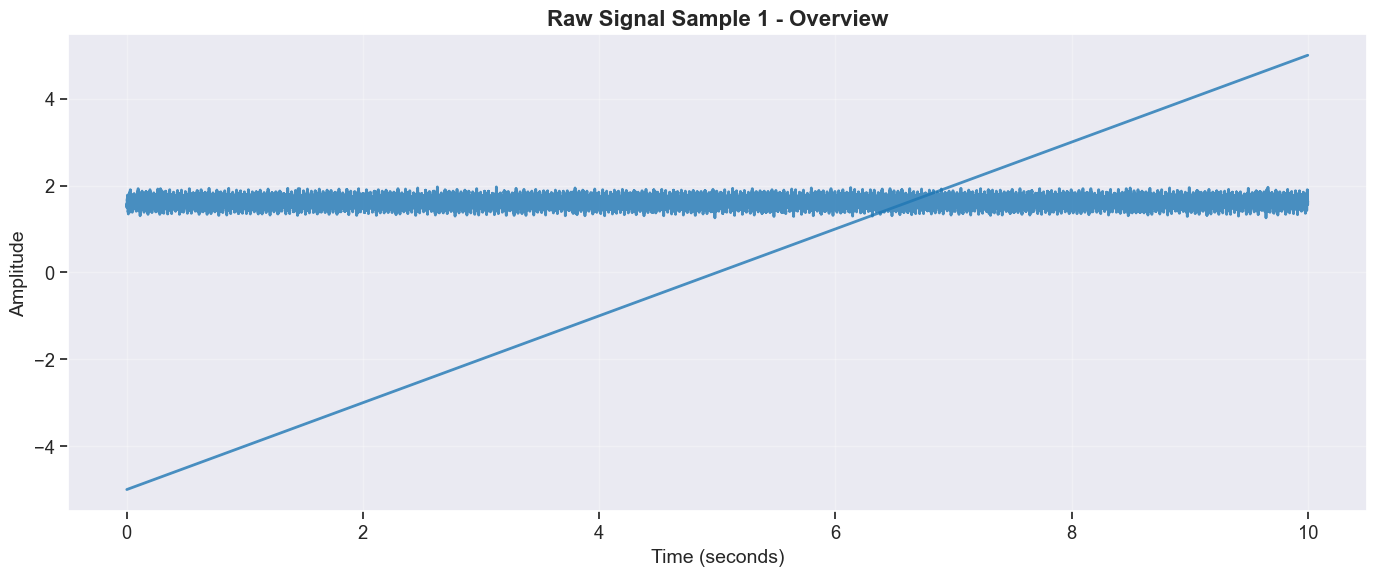

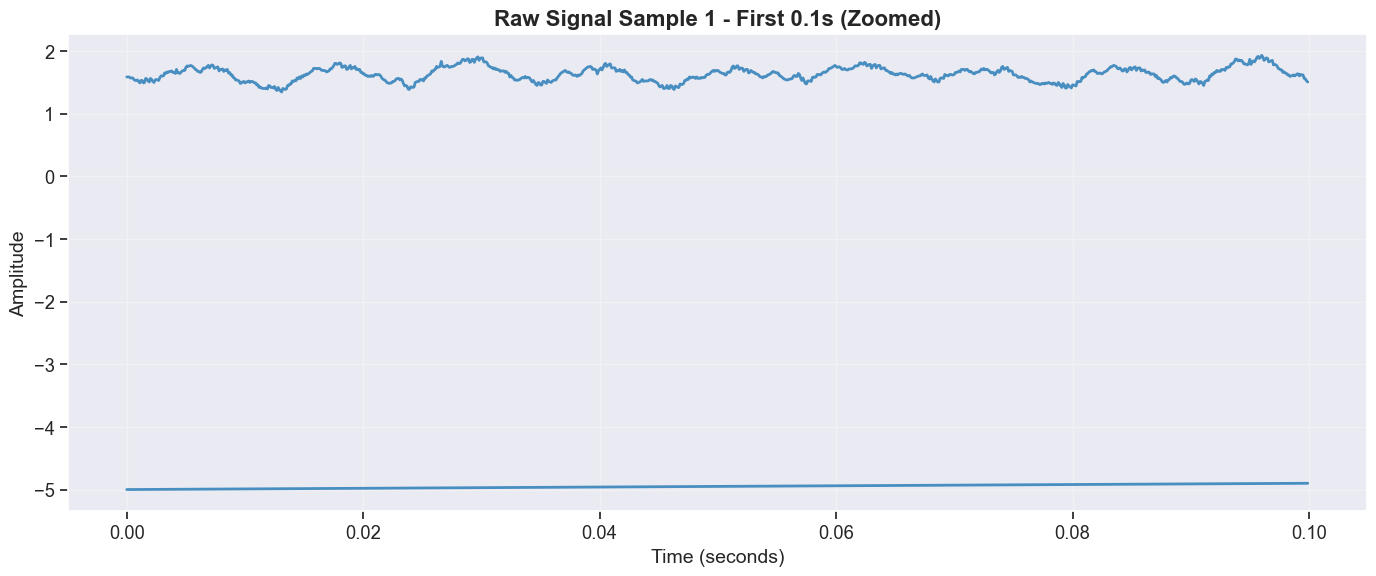

In [4]:
def plot_signal(signal, title, sample_rate=10000):
    """Plots a single signal with professional formatting."""
    time = np.arange(len(signal)) / sample_rate
    
    plt.figure(figsize=(14, 6))
    plt.plot(time, signal, color='#1f77b4', alpha=0.8)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Time (seconds)", fontsize=14)
    plt.ylabel("Amplitude", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize the first sample
if 'data_signals' in locals():
    plot_signal(data_signals[0], "Raw Signal Sample 1 - Overview")
    
    # Zoom in on a smaller section
    plot_signal(data_signals[0][:1000], "Raw Signal Sample 1 - First 0.1s (Zoomed)")

## 3. Feature Extraction
Raw signals are high-dimensional. For ML models, we need to extract meaningful statistical features.
We will extract:
- **Mean**: Central tendency
- **RMS (Root Mean Square)**: Energy content
- **Standard Deviation**: Variability
- **Skewness**: Asymmetry of distribution
- **Kurtosis**: Peakedness of distribution
- **Peak-to-Peak**: Range of the signal

In [5]:
def extract_features(data):
    """Extracts statistical features from the raw signal data."""
    features = []
    print("Extracting features...")
    
    for signal in data:
        # Ensure signal is 1D
        sig = signal.flatten()
        
        f_mean = np.mean(sig)
        f_std = np.std(sig)
        f_rms = np.sqrt(np.mean(sig**2))
        f_skew = stats.skew(sig)
        f_kurt = stats.kurtosis(sig)
        f_p2p = np.ptp(sig)
        f_max = np.max(sig)
        f_min = np.min(sig)
        
        features.append([f_mean, f_std, f_rms, f_skew, f_kurt, f_p2p, f_max, f_min])
        
    feature_names = ['Mean', 'Std_Dev', 'RMS', 'Skewness', 'Kurtosis', 'Peak_to_Peak', 'Max', 'Min']
    return pd.DataFrame(features, columns=feature_names)

if 'data_signals' in locals():
    X_features = extract_features(data_signals)
    print("Feature extraction complete.")
    print(X_features.head())

Extracting features...


d:\Anaconda\Lib\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
d:\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1127: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


Feature extraction complete.
       Mean   Std_Dev       RMS  Skewness  Kurtosis  Peak_to_Peak     Max  Min
0  0.812424  2.198422  2.343735 -0.954404  0.401915        9.9999  4.9999 -5.0
1  0.812372  2.198381  2.343678 -0.954420  0.402061        9.9999  4.9999 -5.0
2  0.812361  2.198395  2.343688 -0.954369  0.401962        9.9999  4.9999 -5.0
3  0.810257  2.197611  2.342223 -0.952925  0.402961        9.9999  4.9999 -5.0
4  0.810458  2.197679  2.342357 -0.953080  0.402902        9.9999  4.9999 -5.0


In [6]:
# Perform Feature Extraction
if 'data_signals' in locals():
    # Extract features from loaded signals
    X_features_df = extract_features(data_signals)
    
    # Add labels
    # Ensure alignment
    min_len = min(len(X_features_df), len(labels_df))
    X_features = X_features_df.iloc[:min_len].copy()
    X_features['Label'] = labels_df.iloc[:min_len, 0].values # Fixed: Column 0 contains class labels (0-6)
    
    print(f"Feature extraction complete. Shape: {X_features.shape}")
    print(X_features.head())
else:
    print("Error: data_signals not loaded. Cannot extract features.")


Extracting features...


d:\Anaconda\Lib\site-packages\numpy\_core\_methods.py:194: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
d:\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1127: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


Feature extraction complete. Shape: (2617, 9)
       Mean   Std_Dev       RMS  Skewness  Kurtosis  Peak_to_Peak     Max  \
0  0.812424  2.198422  2.343735 -0.954404  0.401915        9.9999  4.9999   
1  0.812372  2.198381  2.343678 -0.954420  0.402061        9.9999  4.9999   
2  0.812361  2.198395  2.343688 -0.954369  0.401962        9.9999  4.9999   
3  0.810257  2.197611  2.342223 -0.952925  0.402961        9.9999  4.9999   
4  0.810458  2.197679  2.342357 -0.953080  0.402902        9.9999  4.9999   

   Min  Label  
0 -5.0      0  
1 -5.0      0  
2 -5.0      0  
3 -5.0      0  
4 -5.0      0  


### 3.1 Feature Analysis
Let's analyze the distribution of these features to see if they separate the classes well.

C:\Users\WORKNFLOW\AppData\Local\Temp\ipykernel_16028\1465216750.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='RMS', data=X_features, palette='viridis')


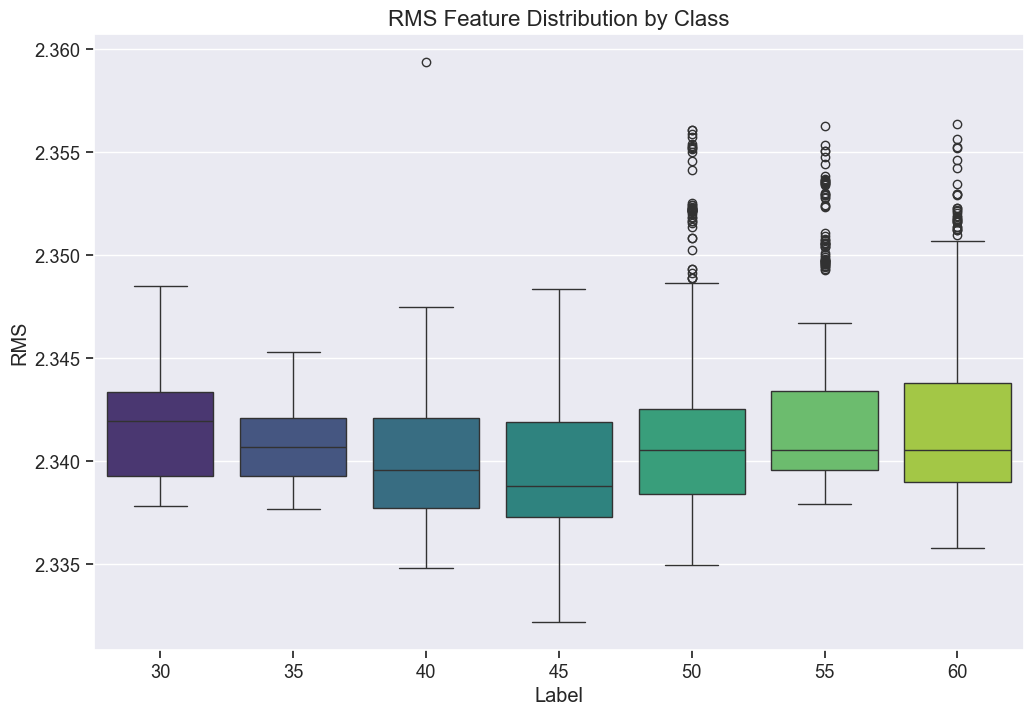

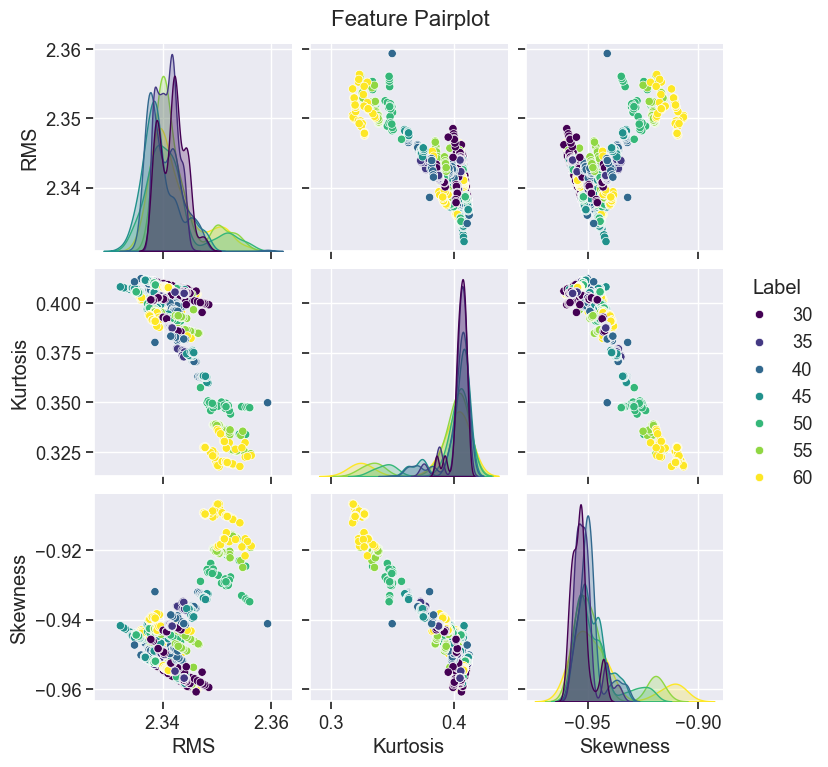

In [7]:
# Add labels to the feature dataframe for visualization
# Note: We need to align labels with data. Assuming 1-to-1 mapping.
# We'll use the 3rd column (index 2) as the class label based on typical formats
if 'data_signals' in locals():
    # Ensure lengths match
    min_len = min(len(X_features), len(labels_df))
    X_features = X_features.iloc[:min_len]
    y_labels = labels_df.iloc[:min_len, 2] # Adjust column index if needed after inspection
    
    X_features['Label'] = y_labels

    # Plot RMS distribution by Class
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Label', y='RMS', data=X_features, palette='viridis')
    plt.title("RMS Feature Distribution by Class", fontsize=16)
    plt.show()
    
    # Pairplot for a subset of features
    sns.pairplot(X_features[['RMS', 'Kurtosis', 'Skewness', 'Label']], hue='Label', palette='viridis')
    plt.suptitle("Feature Pairplot", y=1.02, fontsize=16)
    plt.show()

## 4. Model Training
We will train three standard classifiers:
1. **Random Forest**: Robust and handles non-linearities well.
2. **Support Vector Machine (SVM)**: Effective for high-dimensional spaces.
3. **k-Nearest Neighbors (k-NN)**: Simple and effective baseline.

In [8]:
# Prepare Data
X = X_features.drop('Label', axis=1)
y = X_features['Label']

# Handle NaN and Infinity values
print("Checking for NaN or Infinity values...")
print(f"NaN count before cleaning:\n{X.isna().sum()}")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)
print("Data cleaned.")

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Data (Important for SVM and k-NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Checking for NaN or Infinity values...
NaN count before cleaning:
Mean             0
Std_Dev         15
RMS              0
Skewness        15
Kurtosis        15
Peak_to_Peak     0
Max              0
Min              0
dtype: int64
Data cleaned.
Training samples: 2093
Testing samples: 524



CLASS DISTRIBUTION ANALYSIS

Detected 7 unique classes: [30 35 40 45 50 55 60]

Training Set Distribution:
  Class 30: 290 samples (13.9%)
  Class 35: 304 samples (14.5%)
  Class 40: 303 samples (14.5%)
  Class 45: 290 samples (13.9%)
  Class 50: 290 samples (13.9%)
  Class 55: 320 samples (15.3%)
  Class 60: 296 samples (14.1%)

Test Set Distribution:
  Class 30: 72 samples (13.7%)
  Class 35: 76 samples (14.5%)
  Class 40: 76 samples (14.5%)
  Class 45: 73 samples (13.9%)
  Class 50: 73 samples (13.9%)
  Class 55: 80 samples (15.3%)
  Class 60: 74 samples (14.1%)


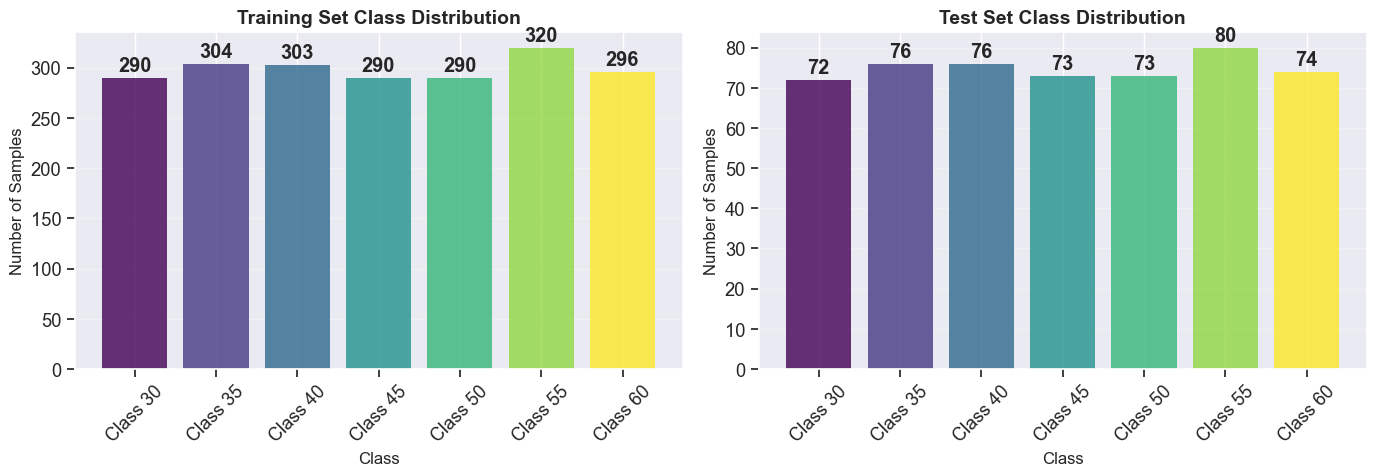


Imbalance Ratio: 1.10:1
Classes are relatively balanced.


In [9]:
# ===== DATA BALANCE ANALYSIS =====
from collections import Counter
import numpy as np

print("\n" + "="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)

# Automatically detect number of classes
unique_classes = np.unique(np.concatenate([y_train, y_test]))
num_classes = len(unique_classes)
print(f"\nDetected {num_classes} unique classes: {unique_classes}")

# Generate class names dynamically
class_names = {cls: f'Class {cls}' for cls in unique_classes}

# Count classes
train_counts = Counter(y_train)
test_counts = Counter(y_test)

print("\nTraining Set Distribution:")
for cls in sorted(train_counts.keys()):
    print(f"  {class_names[cls]}: {train_counts[cls]} samples ({train_counts[cls]/len(y_train)*100:.1f}%)")

print("\nTest Set Distribution:")
for cls in sorted(test_counts.keys()):
    print(f"  {class_names[cls]}: {test_counts[cls]} samples ({test_counts[cls]/len(y_test)*100:.1f}%)")

# Visualize distribution
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_labels = [class_names[i] for i in sorted(train_counts.keys())]
train_values = [train_counts[i] for i in sorted(train_counts.keys())]
colors = plt.cm.viridis(np.linspace(0, 1, len(train_labels)))
axes[0].bar(train_labels, train_values, color=colors, alpha=0.8)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(train_values):
    axes[0].text(i, v + max(train_values)*0.02, str(v), ha='center', fontweight='bold')

# Test set
test_labels = [class_names[i] for i in sorted(test_counts.keys())]
test_values = [test_counts[i] for i in sorted(test_counts.keys())]
axes[1].bar(test_labels, test_values, color=colors, alpha=0.8)
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(test_values):
    axes[1].text(i, v + max(test_values)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Check for imbalance
max_count = max(train_counts.values())
min_count = min(train_counts.values())
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("WARNING: Significant class imbalance detected!")
    print("   Consider using SMOTE, class weights, or balanced sampling.")
else:
    print("Classes are relatively balanced.")


In [10]:
# Initialize Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5)
}

# Train and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")
    print("-" * 30)

Training Random Forest...
Random Forest Accuracy: 0.8416
------------------------------
Training SVM...
SVM Accuracy: 0.3168
------------------------------
Training k-NN...
k-NN Accuracy: 0.7824
------------------------------


## 5. Evaluation and Visualization
We will visualize the performance using Confusion Matrices to see exactly where the models might be misclassifying.

Best Model: Random Forest with 0.8416 accuracy


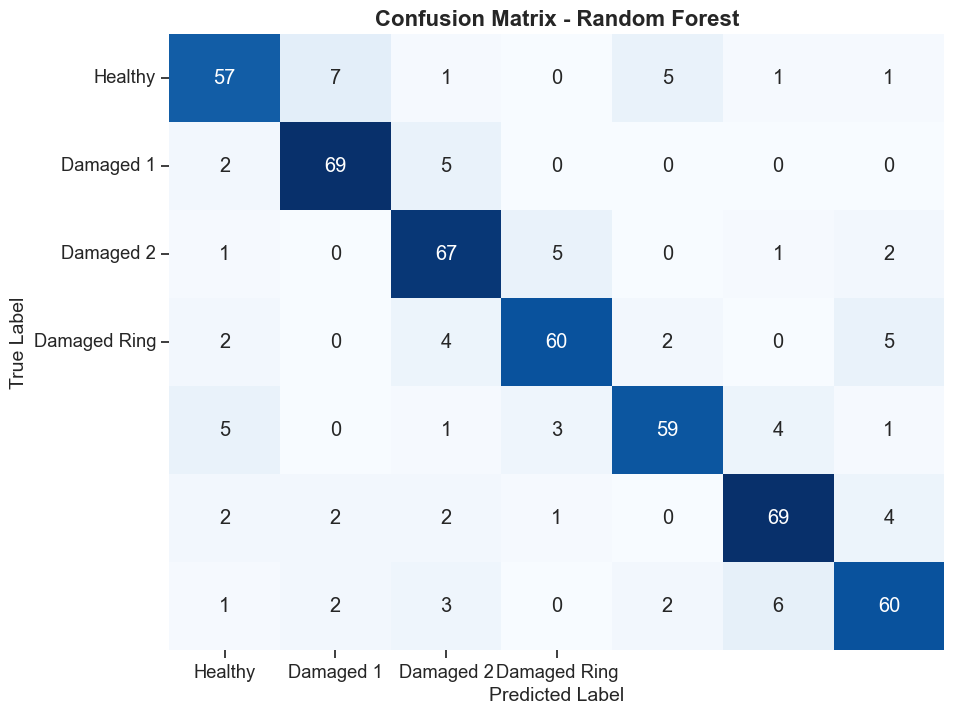

In [11]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
    """Plots a professional confusion matrix."""
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Healthy', 'Damaged 1', 'Damaged 2', 'Damaged Ring'],
                yticklabels=['Healthy', 'Damaged 1', 'Damaged 2', 'Damaged Ring'])
    plt.title(f"Confusion Matrix - {model_name}", fontsize=16, fontweight='bold')
    plt.xlabel("Predicted Label", fontsize=14)
    plt.ylabel("True Label", fontsize=14)
    plt.show()

# Plot for the best model
best_model_name = max(results, key=results.get)
print(f"Best Model: {best_model_name} with {results[best_model_name]:.4f} accuracy")

plot_confusion_matrix(models[best_model_name], X_test_scaled, y_test, best_model_name)

## 6. Conclusion
This notebook demonstrated the effectiveness of ML models on the Induction Motor dataset. 
The trained models can now be saved and integrated into the Digital Twin framework.

In [12]:
# Save the best model
import os

save_dir = "../Trained_models/Induction_Motor_ML"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, f"best_model_{best_model_name.replace(' ', '_')}.pkl")
scaler_path = os.path.join(save_dir, "scaler.pkl")

joblib.dump(models[best_model_name], model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: ../Trained_models/Induction_Motor_ML\best_model_Random_Forest.pkl
Scaler saved to: ../Trained_models/Induction_Motor_ML\scaler.pkl
